In [113]:
import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
import scipy.stats as stats

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit

import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta

# XGBoost Model for Time Series

In this notebook we'll have a look at the XGBoost model to tackle our time series with it.

In [114]:
# First we need to read our data and bring it in the right format.
df = pd.read_csv('../../data_cleaned/merged/02_4_clean_data.csv')
df.head()

,date,year,month,day,dayofyear,hour,dayofweek,price,period_start_utc,period_end_utc,...,res_sum_da,dayofyear_sin1,dayofyear_cos1,hour_sin1,hour_cos1,dayofweek_sin1,dayofweek_cos1,is_holiday,day_type,price_gas
0,2019-01-01,2019,1,1,1,0,1,10.07,2019-01-01 00:00:00+00:00,2019-01-01 01:00:00+00:00,...,25669.0050,0.0,1.0,0.000000,1.000000,0.781831,0.62349,1,holiday,22.28
1,2019-01-01,2019,1,1,1,1,1,-4.08,2019-01-01 01:00:00+00:00,2019-01-01 02:00:00+00:00,...,27384.1025,0.0,1.0,0.258819,0.965926,0.781831,0.62349,1,holiday,22.28
2,2019-01-01,2019,1,1,1,2,1,-9.91,2019-01-01 02:00:00+00:00,2019-01-01 03:00:00+00:00,...,29010.1275,0.0,1.0,0.500000,0.866025,0.781831,0.62349,1,holiday,22.28
3,2019-01-01,2019,1,1,1,3,1,-7.41,2019-01-01 03:00:00+00:00,2019-01-01 04:00:00+00:00,...,30359.5675,0.0,1.0,0.707107,0.707107,0.781831,0.62349,1,holiday,22.28
4,2019-01-01,2019,1,1,1,4,1,-12.55,2019-01-01 04:00:00+00:00,2019-01-01 05:00:00+00:00,...,31409.2100,0.0,1.0,0.866025,0.500000,0.781831,0.62349,1,holiday,22.28


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61367 entries, 0 to 61366
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              61367 non-null  object 
 1   year              61367 non-null  int64  
 2   month             61367 non-null  int64  
 3   day               61367 non-null  int64  
 4   dayofyear         61367 non-null  int64  
 5   hour              61367 non-null  int64  
 6   dayofweek         61367 non-null  int64  
 7   price             61367 non-null  float64
 8   period_start_utc  61367 non-null  object 
 9   period_end_utc    61367 non-null  object 
 10  load_forecast_da  61367 non-null  float64
 11  off_wind_da       61367 non-null  float64
 12  on_wind_da        61367 non-null  float64
 13  solar_da          61367 non-null  float64
 14  gen_forecast_da   61367 non-null  float64
 15  res_sum_da        61367 non-null  float64
 16  dayofyear_sin1    61367 non-null  float6

Our working data after an extensive cleanup phase contains the main columns to train our model:

 - date information in absolute values and fourier transformed values (year, month, hour, day of year, day of week and in sin/cos form)
 - information on the expected amount of renewable energy in the system (res as a combination of solar and offshore/onshore wind)
 - information on the expected load on the grid (load -> demand)
 - information on the expected generated energy in the system (gen -> supply)
 - information on the expected gas price for the day (price_gas)

We want to predict the prices for energy for the next day
 - target value = price

In [116]:
# We need to apply some data manipulation

# 1. use one hot-encoding for the years
df = pd.get_dummies(df, columns=['year'], drop_first=True)

# 2. convert the starting time stamp into a date format without time zone information
df["period_start_utc"] = pd.to_datetime(df["period_start_utc"], errors="coerce")
df["period_start_utc"] = df["period_start_utc"].apply(lambda x: x.replace(tzinfo=None))
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# 3. use the starting time as the index for our data table
df.set_index('period_start_utc', inplace=True)

df.head()

,date,month,day,dayofyear,hour,dayofweek,price,period_end_utc,load_forecast_da,off_wind_da,...,dayofweek_cos1,is_holiday,day_type,price_gas,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025
period_start_utc,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,2019-01-01,1,1,1,0,1,10.07,2019-01-01 01:00:00+00:00,41692.5650,5042.4425,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
2019-01-01 01:00:00,2019-01-01,1,1,1,1,1,-4.08,2019-01-01 02:00:00+00:00,40587.2325,5028.4175,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
2019-01-01 02:00:00,2019-01-01,1,1,1,2,1,-9.91,2019-01-01 03:00:00+00:00,40308.2500,4977.6500,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
2019-01-01 03:00:00,2019-01-01,1,1,1,3,1,-7.41,2019-01-01 04:00:00+00:00,40659.5750,4907.4000,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
2019-01-01 04:00:00,2019-01-01,1,1,1,4,1,-12.55,2019-01-01 05:00:00+00:00,40947.7300,4882.8400,...,0.62349,1,holiday,22.28,False,False,False,False,False,False


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61367 entries, 2019-01-01 00:00:00 to 2025-12-31 22:00:00
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              61367 non-null  datetime64[ns]
 1   month             61367 non-null  int64         
 2   day               61367 non-null  int64         
 3   dayofyear         61367 non-null  int64         
 4   hour              61367 non-null  int64         
 5   dayofweek         61367 non-null  int64         
 6   price             61367 non-null  float64       
 7   period_end_utc    61367 non-null  object        
 8   load_forecast_da  61367 non-null  float64       
 9   off_wind_da       61367 non-null  float64       
 10  on_wind_da        61367 non-null  float64       
 11  solar_da          61367 non-null  float64       
 12  gen_forecast_da   61367 non-null  float64       
 13  res_sum_da        61367 non-null  float64

# Choosing a time frame for our time series

Next we want to choose a time frame for our data series. So first we need to decide the interval on which the model should be trained. We decide to use all the date starting from 2019 up until the end of january 2025. Even though, we aim to just predict the next day of our current model, we'll also want to see how the model will perform over an extended period of time without training. For this we install some global variables, that we are going to use in the future.

In [118]:
start_date = pd.to_datetime('2019-01-01 00:00:00')
split_date = pd.to_datetime('2025-02-01 00:00:00')
end_date = pd.to_datetime('2026-01-01 00:00:00')

Let us visualize our test and training data:

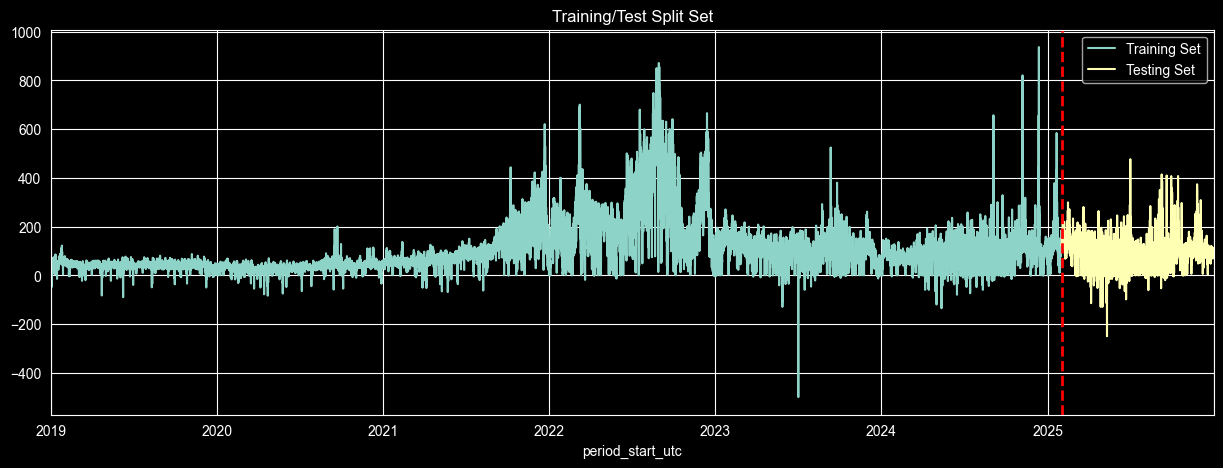

In [119]:
train = df.query('@start_date <= date < @split_date')
test = df.query('@split_date <= date < @end_date')

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(y='price', ax=ax, label='Training Set', title='Training/Test Split Set')
test.plot(y='price', ax=ax, label = 'Testing Set')
ax.axvline(split_date, color='red', linestyle='dashed', linewidth=2)
plt.legend()
plt.show()

As we can see from our data, we have some relative smooth 2,5 years at the beginning. Then international tensions rose and the Ukraine war started. This had a major impact on raw energy like oil and gas and therefore a similar impact on the electirc energy prices in Europe. Over the time and with new market mechanisms in place created by the respective governments, the energy prices stabilized. However, they never reached the state again as it was in the years before the Ukraine war.

# Creating the first model

We want to start and create our first model. For this we need to decide on the features, that we want to see in it. We are going to use one variant of the complete time information (some absolute and some fourier transformation for the cyclic time components like hours of the day) as well as all the available energy forecast information (load, res, gen and gas prices).

In [120]:
FEATURES = ['load_forecast_da', 'res_sum_da', 'gen_forecast_da', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'price_gas', 'year_2020', 'year_2021', 'year_2022',
       'year_2023', 'year_2024', 'year_2025']
TARGET = 'price'

In [121]:
# create the test sets
X_train = train[FEATURES]
y_train = train[TARGET]

We'll build or model with stats that seem pretty good in our case. These stats were derived from some bigger analysis of the data.

In [122]:
# First we build the regressor
reg = xgb.XGBRegressor(base_score=0.5,
                       n_estimators=1500, # number of trees being created
                       learning_rate=0.01,
                       early_stopping_rounds=500,
                       objective='reg:squarederror',
                       colsample_bytree=0.8,
                       subsample=0.8,
                       max_depth=5,
                       enable_categorial=True)

# Next we fit it to the training data
reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train)],
            verbose=50 # prints the n-th result
            )

[0]	validation_0-rmse:136.64470
[50]	validation_0-rmse:89.57308
[100]	validation_0-rmse:60.34076


C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [14:47:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "enable_categorial" } are not used.

  self.starting_round = model.num_boosted_rounds()


[150]	validation_0-rmse:43.33680
[200]	validation_0-rmse:33.26777
[250]	validation_0-rmse:27.46432
[300]	validation_0-rmse:24.01702
[350]	validation_0-rmse:21.97332
[400]	validation_0-rmse:20.71797
[450]	validation_0-rmse:19.73396
[500]	validation_0-rmse:19.05727
[550]	validation_0-rmse:18.50358
[600]	validation_0-rmse:18.00602
[650]	validation_0-rmse:17.59924
[700]	validation_0-rmse:17.24477
[750]	validation_0-rmse:16.92602
[800]	validation_0-rmse:16.63790
[850]	validation_0-rmse:16.40243
[900]	validation_0-rmse:16.18653
[950]	validation_0-rmse:15.96857
[1000]	validation_0-rmse:15.76990
[1050]	validation_0-rmse:15.58636
[1100]	validation_0-rmse:15.42122
[1150]	validation_0-rmse:15.24935
[1200]	validation_0-rmse:15.11239
[1250]	validation_0-rmse:14.97359
[1300]	validation_0-rmse:14.83752
[1350]	validation_0-rmse:14.70014
[1400]	validation_0-rmse:14.57729
[1450]	validation_0-rmse:14.44406
[1499]	validation_0-rmse:14.32442


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.5
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",500
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[typing.Callable, str]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

Let's see, which of the used features contributed mainly to our model and which features were negligible in this specific run.

Remark: If a feature was negligible in this run does not mean it can easily be omitted in general. The feature importance (as shown in a different notebook about time frame inputs) of unimportant one ran be more important with different training date frames and vice versa. This depends greatly which dates we use for training. As one example we can see in the following graph, that the year 2022 (the crisis year) is very important. However, if you'd only train on the first two years (2019-2020), the years will not be important at all because there is no real trend over the years or a yearly pattern.

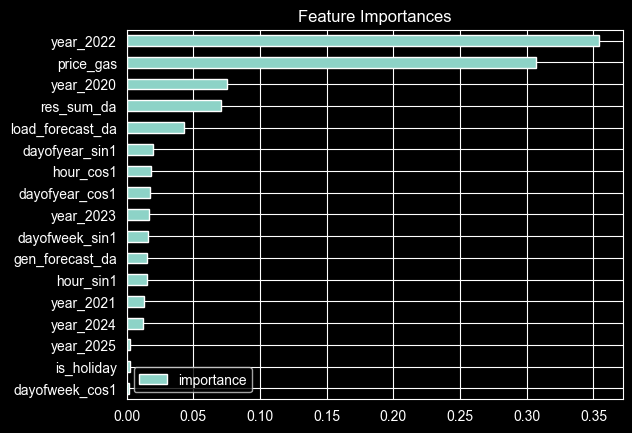

In [123]:
fi = pd.DataFrame(data=reg.feature_importances_,
                  index=reg.feature_names_in_,
                  columns=['importance']
                  )
fi.sort_values('importance').plot(kind='barh', title='Feature Importances')
plt.show()

As mentioned before, one of the most important features for the model is the year 2022. Another very important feature is the gas price because the electrical energy price is closely connected to it. The input or primal energy like gas rose shortly before and during the Ukraine war and the electrical energy price followed.

On the other hand, we have seen in the EDA that the energy prices were very low on public holidays, even lower than on the weekend. However, the importance of public holidays for the model seems neglibile in comparison to the other values.

Let us continue with looking into our predictions. First we need to use the trained model on our test set to predict the values. So we predict one the test data and add this data to our original table.

In [124]:
# predict the values on the test data
test['prediction'] = reg.predict(test[FEATURES])

# merge the predicted data into the original data table
df = df.merge(test[['prediction']],  how = 'left', left_index=True, right_index=True) # merge on index columns

C:\Users\bened\AppData\Local\Temp\ipykernel_23948\2935509.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = reg.predict(test[FEATURES])


In the column 'predictions' of the table test are now all the predictions of the model for the whole time frame from end of training data until the end of our data table.

Since the main purpose of our model is to predict the energy prices for the next day, we calculate the errors represented by the root mean square error and mean absolute error for the first day of test data.

In [125]:
# calculate the root-mean-square error on the test set for the first day after training
rmse_day = root_mean_squared_error(test.query('@split_date.date() == date')[TARGET], test.query('@split_date.date() == date')['prediction'])
print(f'RMSE for the {split_date.date()}: {rmse_day} EUR/MWh')

# calculate the mean absolute error on the test set for the first day after training
mae_day = mean_absolute_error(test.query('@split_date.date() == date')[TARGET], test.query('@split_date.date() == date')['prediction'])
print(f'MAE for the {split_date.date()}: {mae_day} EUR/MWh')

RMSE for the 2025-02-01: 7.959241227496177 EUR/MWh
MAE for the 2025-02-01: 7.13974011739095 EUR/MWh


An RMSE of less than 8 EUR/MWh looks quite nice for our first model. Let's plot the predicted data in comparison to the test data for the first predicted day. We see that the predicted data is quite close to the original test data.

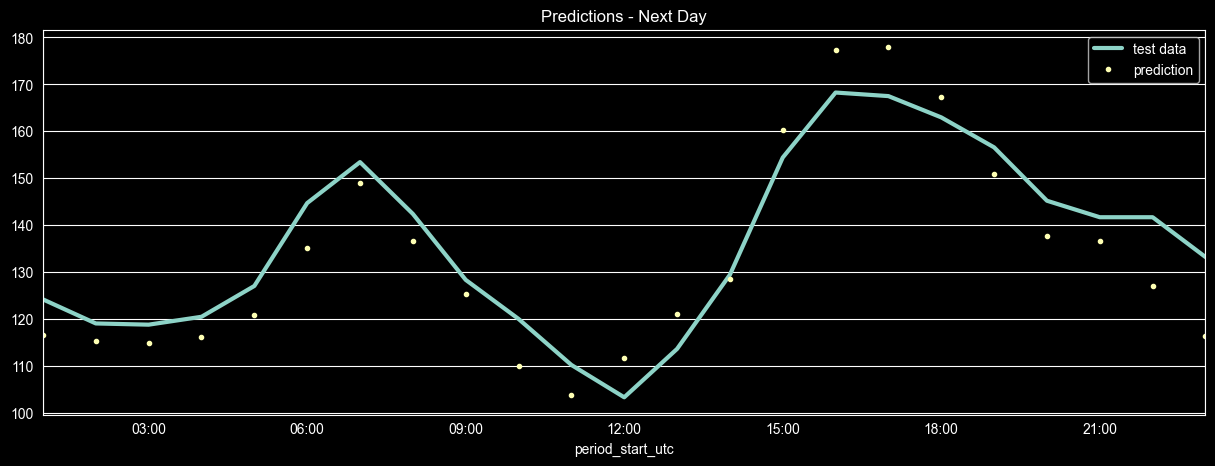

In [126]:
end_of_split_date = split_date + relativedelta(days=1)

ax = df.loc[(split_date < df.index) & (df.index < end_of_split_date)]['price'].plot(figsize=(15, 5), linewidth=3, title='Predictions - Next Day')
df.loc[(split_date < df.index) & (df.index < end_of_split_date)]['prediction'].plot(ax=ax, style='.')
plt.legend(['test data', 'prediction'])
plt.show()

If we want to have a look at longer periods and how good our model predicts longer time frames than just one day, we can calculate the errors for the full test period.

In [127]:
# calculate the root-mean-square error on the complete test set
rmse_period = root_mean_squared_error(test[TARGET], test['prediction'])
print(f'RMSE for the complete test set: {rmse_period} EUR/MWh')

# calculate the mean absolute error on the complete test set
mae_period = mean_absolute_error(test[TARGET], test['prediction'])
print(f'MAE for the complete test set: {mae_period} EUR/MWh')

RMSE for the complete test set: 25.83510277469112 EUR/MWh
MAE for the complete test set: 17.461279414377277 EUR/MWh


As expected the errors rose over a longer period of time, but they are still very good for a prediction of almost a whole year.

Let's plot the predictions in comparison to the test data for the whole test period. The graph is a bt overloaded, but we can clearly see how the predicted data mirrors the test data in general. Only some outliers are very hard to predict.

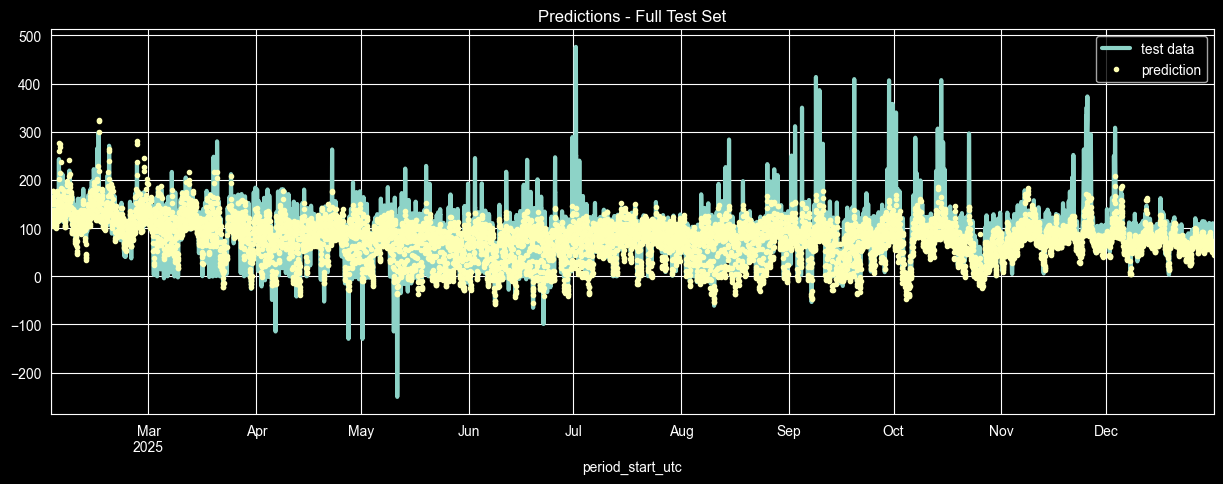

In [128]:
ax = df.loc[(split_date < df.index)]['price'].plot(figsize=(15, 5), linewidth=3, title='Predictions - Full Test Set')
df.loc[(split_date < df.index)]['prediction'].plot(ax=ax, style='.')
plt.legend(['test data', 'prediction'])
plt.show()

# Grid Search for XGBoost

In the last chapter we have seen how we trained a XGBoost model with preset hyperparameters. However, we can also use grid search or random search for hyperpatamer optimization.

Let's start with grid search. We can define a simple grid in order to find some optimal hyperparameters for our XGBoost model.

In [129]:
# Using Grid Search
# Define the hyperparameter distributions
param_grid = {
    'base_score': [0.5],
    'max_depth': np.arange(4, 7, 1).tolist(),
    'learning_rate': np.arange(0.01, 0.2, 0.9).tolist(),
    'subsample': [0.8],
    'n_estimators': np.arange(1100, 1500, 200).tolist(),
    'colsample_bytree': [0.8],
    'objective': ['reg:squarederror'],
}

We can also define a bigger grid to find better parameters. However, this larger grid will take a lot longer than our simple grid. Therefore, it is commented out. If you want to try it, you can uncomment it. Be warned, this might run longer than an hour, but can also yield better results.

In [130]:
# Define the hyperparameter distributions. This is a larger grid and will take much longer to run. Hence, it is commented out.
#param_grid = {
#    'base_score':[0.5],
#    'max_depth': np.arange(3, 8, 1).tolist(),
#    'learning_rate': np.arange(0.01, 0.2, 0.03).tolist(),
#    'subsample': [0.8],
#    'n_estimators': np.arange(1000, 2000, 200).tolist(),
#    'colsample_bytree': np.arange(0.7, 0.9, 0.1).tolist(),
#    'objective':['reg:squarederror'],
#}

With the parameters for the grid search defined, let us run the grid search model. For cross validation we are going to use the special mode of TimeSeriesSplit in order to prevent data leakage.

In [131]:
# Redefine the training data again
X_train = train[FEATURES]
y_train = train[TARGET]

# Create the XGBoost model object
xgb_model = xgb.XGBRegressor()

# Create the GridSearchCV object
grid_search = GridSearchCV(xgb_model, param_grid, cv=TimeSeriesSplit(n_splits=5), scoring='neg_root_mean_squared_error', n_jobs=5)

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Print the best set of hyperparameters and the corresponding score
print("Best set of hyperparameters: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

# Save the best grid model
grid_search_best_model = grid_search.best_estimator_

Best set of hyperparameters:  {'base_score': 0.5, 'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 1300, 'objective': 'reg:squarederror', 'subsample': 0.8}
Best score:  -58.25579134527292


We can see from the output what the best set for our hyperparameters should be. Remark, that the best values of hyperparameters might change drastically with using a different parameter grid, like the one commented out.

Let us run the best model on our test data to be able to compare the predictions with the target price of the resting data.

In [132]:
# predict the values on the test data
test['prediction_grid_search'] = grid_search_best_model.predict(test[FEATURES])

# merge the predicted data into the original data table
df = df.merge(test[['prediction_grid_search']],  how = 'left', left_index=True, right_index=True) # merge on index columns

With the predictions of the best model we can calculate our errors and compare them with the values of our static run. The result shows us, that we have found quite some good hyperparameters for the XGBoost model.

In [151]:
# calculate the root-mean-square error on the test set for the first day after training
rmse_day_grid_search = root_mean_squared_error(test.query('@split_date.date() == date')[TARGET], test.query('@split_date.date() == date')['prediction_grid_search'])
print(f'RMSE with grid search for the {split_date.date()}: {rmse_day_grid_search} EUR/MWh')

# calculate the mean absolute error on the test set for the first day after training
mae_day_grid_search = mean_absolute_error(test.query('@split_date.date() == date')[TARGET], test.query('@split_date.date() == date')['prediction_grid_search'])
print(f'MAE with grid search for the {split_date.date()}: {mae_day_grid_search} EUR/MWh')

RMSE for the 2025-02-01: 9.920194492843306 EUR/MWh
MAE for the 2025-02-01: 8.598707962036132 EUR/MWh


In [133]:
# calculate the root-mean-square error on the complete test set
rmse_period_grid_search = root_mean_squared_error(test[TARGET], test['prediction_grid_search'])
print(f'RMSE with grid search on the complete test set: {rmse_period_grid_search} EUR/MWh')

# calculate the mean absolute error on the complete test set
mae_period_grid_search = mean_absolute_error(test[TARGET], test['prediction_grid_search'])
print(f'MAE with grid search on the complete test set: {mae_period_grid_search} EUR/MWh')

RMSE with grid search on the complete test set: 27.10030633084968 EUR/MWh
MAE with grid search on the complete test set: 18.40857685213732 EUR/MWh


# Random Search with XGBoost

Let us also run now the random search in combination with XGBoost. This works pretty much the same way that the grid search worked. However, one advantage for the random search is always that it might find a good model sooner since it does not need to try out every combination on the parameter grid.

So let's define the parameter distribution for the random search.

In [134]:
# Define the hyperparameter distributions
param_dist = {
    'base_score':stats.uniform(0.3, 0.7),
    'max_depth': stats.randint(3, 10),
    'learning_rate': stats.uniform(0.001, 0.2),
    'subsample': stats.uniform(0.5, 0.9),
    'n_estimators':stats.randint(200, 2000),
    'colsample_bytree':stats.uniform(0.5, 0.8)
}

With the parameters for the random search defined, let us run the random search model. For cross validation we are going to use the special mode of TimeSeriesSplit again in order to prevent data leakage.

In [135]:
# Redefine the training data again
X_train = train[FEATURES]
y_train = train[TARGET]

# Create the GridSearchCV object
random_search = RandomizedSearchCV(xgb_model, param_distributions=param_dist, n_iter=20, cv=TimeSeriesSplit(n_splits=5), scoring='neg_root_mean_squared_error')

# Fit the RandomizedSearchCV object to the training data
random_search.fit(X_train, y_train)

# Print the best set of hyperparameters and the corresponding score
print("Best set of hyperparameters: ", random_search.best_params_)
print("Best score: ", random_search.best_score_)

# Save the best random model
random_search_best_model = random_search.best_estimator_

C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
70 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "C:\Users\bened\D

Best set of hyperparameters:  {'base_score': 0.7152897109724485, 'colsample_bytree': 0.6420944120281025, 'learning_rate': 0.1770589424280028, 'max_depth': 4, 'n_estimators': 466, 'subsample': 0.6097437873845639}
Best score:  -56.54904038208133


Let us run the best model on our test data to be able to compare the predictions with the target price of the resting data

In [136]:
# predict the values on the test data
test['prediction_random_search'] = random_search_best_model.predict(test[FEATURES])

# merge the predicted data into the original data table
df = df.merge(test[['prediction_random_search']],  how = 'left', left_index=True, right_index=True) # merge on index columns

For the random search we used a bigger "grid". However, since we are not looking at every single grid point anymore, the search concludes a lot faster. In addition we found a better set of parameters than we have found in the grid search, yielding better errors. It is also better than the one of our original model.

In [152]:
# calculate the root-mean-square error on the test set for the first day after training
rmse_day_random_search = root_mean_squared_error(test.query('@split_date.date() == date')[TARGET], test.query('@split_date.date() == date')['prediction_random_search'])
print(f'RMSE with random search for the {split_date.date()}: {rmse_day_random_search} EUR/MWh')

# calculate the mean absolute error on the test set for the first day after training
mae_day_random_search = mean_absolute_error(test.query('@split_date.date() == date')[TARGET], test.query('@split_date.date() == date')['prediction_random_search'])
print(f'MAE with random search for the {split_date.date()}: {mae_day_random_search} EUR/MWh')

RMSE for the 2025-02-01: 8.5725332546335 EUR/MWh
MAE for the 2025-02-01: 5.77345848083496 EUR/MWh


In [137]:
# calculate the root-mean-square error on the complete test set
rmse_period_random_search = root_mean_squared_error(test[TARGET], test['prediction_random_search'])
print(f'RMSE with random search on the complete test set: {rmse_period_random_search} EUR/MWh')

# calculate the mean absolute error on the complete test set
mae_period_random_search = mean_absolute_error(test[TARGET], test['prediction_random_search'])
print(f'MAE with random search on the complete test set: {mae_period_random_search} EUR/MWh')

RMSE with grid search on the complete test set: 22.893164157897147 EUR/MWh
MAE with random search on the complete test set: 14.391005524503948 EUR/MWh


We can plot the three models (original, grid search, random search) for a head to head visualization. We choose the timeframe of one week. Remark that the errors were run at the whole test set.

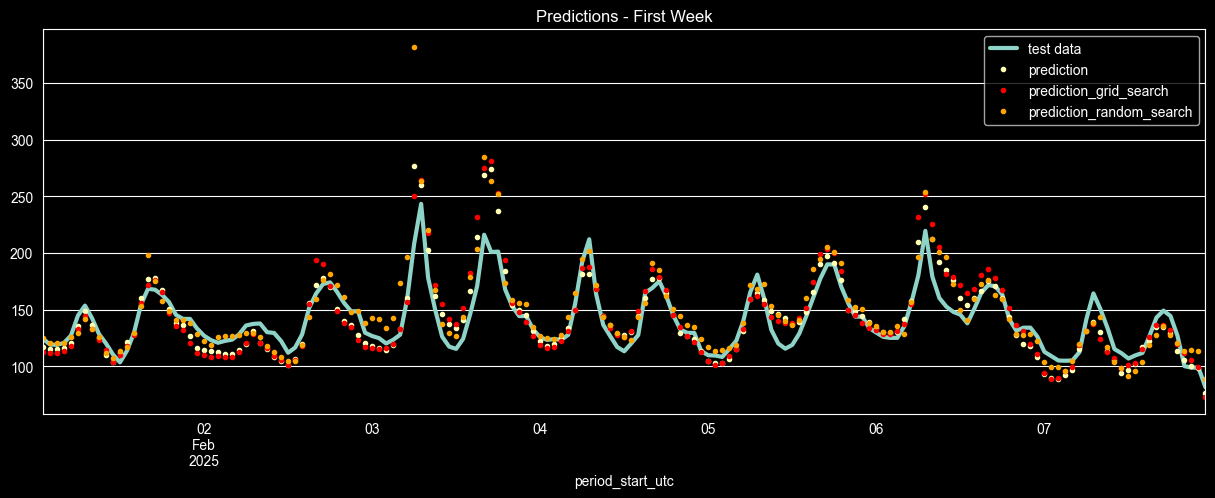

In [138]:
split_date_plus_one_week = split_date + relativedelta(days=7)

ax = df.loc[(split_date < df.index) & (df.index < split_date_plus_one_week)]['price'].plot(figsize=(15, 5), linewidth=3, title='Predictions - First Week')
df.loc[(split_date < df.index) & (df.index < split_date_plus_one_week)]['prediction'].plot(ax=ax, style='.')
df.loc[(split_date < df.index) & (df.index < split_date_plus_one_week)]['prediction_grid_search'].plot(ax=ax, style='.', color='red')
df.loc[(split_date < df.index) & (df.index < split_date_plus_one_week)]['prediction_random_search'].plot(ax=ax, style='.', color='orange')
plt.legend(['test data', 'prediction', 'prediction_grid_search', 'prediction_random_search'])
plt.show()

At least from th visual perspective it looks quite often that the random search looks closest to the test data plot.

# Lagging for Time Series and XGBoost

One important aspect of feature engineering for time series besides One-Hot-Encoding and Fast-Fourier Transformation is the concept of lagging. This concept connects the values of one time stamp with some previous time stamp.

In our case we want to lag the gas prices. We choose the gas prices, because they seem to have a high importance in every model so far. So we want to make the history of gas prices known to a certain time stamp. The gas price is constant in one day. So we are lagging days. Specifically we will try to lag three days and one week. Hence, lets add the original price values for up to 7 days. Remark that uor data is hourly in the tables. Hence, lagging by one day means that we need to lag 24 rows for 24 hours.

In [139]:
# Lag the gas prices and create a new column for each lagged day
df[f'gas_price_lag_1days'] = df['price_gas'].shift(periods=1*24)
df[f'gas_price_lag_2days'] = df['price_gas'].shift(periods=2*24)
df[f'gas_price_lag_3days'] = df['price_gas'].shift(periods=3*24)
df[f'gas_price_lag_4days'] = df['price_gas'].shift(periods=4*24)
df[f'gas_price_lag_5days'] = df['price_gas'].shift(periods=5*24)
df[f'gas_price_lag_6days'] = df['price_gas'].shift(periods=6*24)
df[f'gas_price_lag_7days'] = df['price_gas'].shift(periods=7*24)
df.head()

,date,month,day,dayofyear,hour,dayofweek,price,period_end_utc,load_forecast_da,off_wind_da,...,prediction,prediction_grid_search,prediction_random_search,gas_price_lag_1days,gas_price_lag_2days,gas_price_lag_3days,gas_price_lag_4days,gas_price_lag_5days,gas_price_lag_6days,gas_price_lag_7days
period_start_utc,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,2019-01-01,1,1,1,0,1,10.07,2019-01-01 01:00:00+00:00,41692.5650,5042.4425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00,2019-01-01,1,1,1,1,1,-4.08,2019-01-01 02:00:00+00:00,40587.2325,5028.4175,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00,2019-01-01,1,1,1,2,1,-9.91,2019-01-01 03:00:00+00:00,40308.2500,4977.6500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00,2019-01-01,1,1,1,3,1,-7.41,2019-01-01 04:00:00+00:00,40659.5750,4907.4000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00,2019-01-01,1,1,1,4,1,-12.55,2019-01-01 05:00:00+00:00,40947.7300,4882.8400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We will need to create a new training data set, because the first few days are missing data in the lagging columns. Hence, we omit the first week of 2019 from our training data. This will create a negligible discrepency between this training data and the one for the previous models.

In [140]:
start_date_lag = start_date + relativedelta(days=8)
train_lag = df.query('@start_date_lag <= date < @split_date')
test_lag = df.query('@split_date <= date < @end_date')

First we focus on a lag of 3 days. For this we add the right columns to our feature list. This means we add the lagging gas prices for up to 3 days.

In [141]:
FEATURES_lag_3days = ['load_forecast_da', 'res_sum_da', 'gen_forecast_da', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'year_2020', 'year_2021', 'year_2022',
       'year_2023', 'year_2024', 'year_2025', 'price_gas', 'gas_price_lag_1days', 'gas_price_lag_2days', 'gas_price_lag_3days']
TARGET = 'price'

For the XGBoost model we use the stats of the original model.

In [142]:
# create the test sets
X_train_lag_3days = train_lag[FEATURES_lag_3days]
y_train_lag_3days = train_lag[TARGET]

# First we build the regressor
reg_lag_3days = xgb.XGBRegressor(base_score=0.5,
                                 n_estimators=1500,  # number of trees being created
                                 learning_rate=0.01,
                                 early_stopping_rounds=500,
                                 objective='reg:squarederror',
                                 colsample_bytree=0.8,
                                 subsample=0.8,
                                 max_depth=5,
                                 enable_categorial=True)

# Next we fit it to the training data
reg_lag_3days.fit(X_train_lag_3days, y_train_lag_3days,
                  eval_set=[(X_train_lag_3days, y_train_lag_3days)],
                  verbose=50  # prints the n-th result
                  )

[0]	validation_0-rmse:136.82253
[50]	validation_0-rmse:87.90657


C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [14:49:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "enable_categorial" } are not used.

  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:58.82159
[150]	validation_0-rmse:41.83536
[200]	validation_0-rmse:32.01813
[250]	validation_0-rmse:26.45446
[300]	validation_0-rmse:23.14638
[350]	validation_0-rmse:21.04801
[400]	validation_0-rmse:19.67271
[450]	validation_0-rmse:18.70576
[500]	validation_0-rmse:18.01383
[550]	validation_0-rmse:17.46140
[600]	validation_0-rmse:17.04312
[650]	validation_0-rmse:16.68059
[700]	validation_0-rmse:16.35414
[750]	validation_0-rmse:16.05667
[800]	validation_0-rmse:15.78919
[850]	validation_0-rmse:15.54078
[900]	validation_0-rmse:15.33133
[950]	validation_0-rmse:15.12982
[1000]	validation_0-rmse:14.93384
[1050]	validation_0-rmse:14.74239
[1100]	validation_0-rmse:14.57511
[1150]	validation_0-rmse:14.41000
[1200]	validation_0-rmse:14.26380
[1250]	validation_0-rmse:14.12310
[1300]	validation_0-rmse:13.99045
[1350]	validation_0-rmse:13.86270
[1400]	validation_0-rmse:13.73628
[1450]	validation_0-rmse:13.61620
[1499]	validation_0-rmse:13.51299


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.5
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",500
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[typing.Callable, str]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

Let us run the best model on our test data to be able to compare the predictions with the target price of the resting data.

In [143]:
# predict the values on the test data
test_lag['prediction_lag_3days'] = reg_lag_3days.predict(test_lag[FEATURES_lag_3days])

# merge the predicted data into the original data table
df = df.merge(test_lag[['prediction_lag_3days']],  how = 'left', left_index=True, right_index=True) # merge on index columns

C:\Users\bened\AppData\Local\Temp\ipykernel_23948\4111383288.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_lag['prediction_lag_3days'] = reg_lag_3days.predict(test_lag[FEATURES_lag_3days])


The RMSE and MAE values for the 3 day lagging gas prices look quite good, however it is not a big improvement to our original model.

In [153]:
# calculate the root-mean-square error on the test set for the first day after training
rmse_day_lag_3days = root_mean_squared_error(test_lag.query('@split_date.date() == date')[TARGET], test_lag.query('@split_date.date() == date')['prediction_lag_3days'])
print(f'RMSE with 3 days lag for gas prices for the {split_date.date()}: {rmse_day_lag_3days} EUR/MWh')

# calculate the mean absolute error on the test set for the first day after training
mae_day_lag_3days = mean_absolute_error(test_lag.query('@split_date.date() == date')[TARGET], test_lag.query('@split_date.date() == date')['prediction_lag_3days'])
print(f'MAE with 3 days lag for gas prices for the {split_date.date()}: {mae_day_lag_3days} EUR/MWh')

RMSE with 3 days lag for gas prices for the 2025-02-01: 9.352355026514878 EUR/MWh
MAE with 3 days lag for gas prices for the 2025-02-01: 8.306763458251952 EUR/MWh


In [154]:
# calculate the root-mean-square error on the complete test set
rmse_period_lag_3days = root_mean_squared_error(test_lag[TARGET], test_lag['prediction_lag_3days'])
print(f'RMSE with 3 days lag for gas prices on the complete test set: {rmse_period_lag_3days} EUR/MWh')

# calculate the mean absolute error on the complete test set
mae_period_lag_3days = mean_absolute_error(test_lag[TARGET], test_lag['prediction_lag_3days'])
print(f'MAE with 3 days lag for gas prices on the complete test set: {mae_period_lag_3days} EUR/MWh')

RMSE with 3 days lag for gas prices on the complete test set: 26.84845732475196 EUR/MWh
MAE with 3 days lag for gas prices on the complete test set: 18.554680858372368 EUR/MWh


Let us try the same with 7 days of lagging gas prices.

In [145]:
FEATURES_lag_7days = ['load_forecast_da', 'res_sum_da', 'gen_forecast_da', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'year_2020', 'year_2021', 'year_2022',
       'year_2023', 'year_2024', 'year_2025', 'price_gas', 'gas_price_lag_1days', 'gas_price_lag_2days', 'gas_price_lag_3days', 'gas_price_lag_4days', 'gas_price_lag_5days', 'gas_price_lag_6days', 'gas_price_lag_7days']
TARGET = 'price'

For the XGBoost model we use the stats of the original model which are also the same as for the 3 days lagging gas prices model.

In [146]:
# create the test sets
X_train_lag_7days = train_lag[FEATURES_lag_7days]
y_train_lag_7days = train_lag[TARGET]

# First we build the regressor
reg_lag_7days = xgb.XGBRegressor(base_score=0.5,
                       n_estimators=1500, # number of trees being created
                       learning_rate=0.01,
                       early_stopping_rounds=500,
                       objective='reg:squarederror',
                       colsample_bytree=0.8,
                       subsample=0.8,
                       max_depth=5,
                       enable_categorial=True)

# Next we fit it to the training data
reg_lag_7days.fit(X_train_lag_7days, y_train_lag_7days,
            eval_set=[(X_train_lag_7days, y_train_lag_7days)],
            verbose=50 # prints the n-th result
            )

[0]	validation_0-rmse:136.78189


C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [14:49:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "enable_categorial" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	validation_0-rmse:87.93004
[100]	validation_0-rmse:59.08897
[150]	validation_0-rmse:42.01048
[200]	validation_0-rmse:32.14037
[250]	validation_0-rmse:26.48547
[300]	validation_0-rmse:23.11700
[350]	validation_0-rmse:21.00157
[400]	validation_0-rmse:19.65623
[450]	validation_0-rmse:18.67496
[500]	validation_0-rmse:17.95790
[550]	validation_0-rmse:17.41271
[600]	validation_0-rmse:16.98940
[650]	validation_0-rmse:16.62123
[700]	validation_0-rmse:16.29607
[750]	validation_0-rmse:16.00142
[800]	validation_0-rmse:15.73821
[850]	validation_0-rmse:15.49972
[900]	validation_0-rmse:15.27993
[950]	validation_0-rmse:15.07076
[1000]	validation_0-rmse:14.87102
[1050]	validation_0-rmse:14.69092
[1100]	validation_0-rmse:14.51689
[1150]	validation_0-rmse:14.35701
[1200]	validation_0-rmse:14.20451
[1250]	validation_0-rmse:14.06796
[1300]	validation_0-rmse:13.93598
[1350]	validation_0-rmse:13.79884
[1400]	validation_0-rmse:13.66657
[1450]	validation_0-rmse:13.55063
[1499]	validation_0-rmse:13.43759


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.5
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",500
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[typing.Callable, str]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

Let us run the best model on our test data to be able to compare the predictions with the target price of the resting data.

In [147]:
# predict the values on the test data
test_lag['prediction_lag_7days'] = reg_lag_7days.predict(test_lag[FEATURES_lag_7days])

# merge the predicted data into the original data table
df = df.merge(test_lag[['prediction_lag_7days']],  how = 'left', left_index=True, right_index=True) # merge on index columns

The RMSE and MAE for 7 days of lagging gas prices are slightly worse for the complete testing set than just 3 days of lagging gas prices.


In [155]:
# calculate the root-mean-square error on the test set for the first day after training
rmse_day_lag_7days = root_mean_squared_error(test_lag.query('@split_date.date() == date')[TARGET], test_lag.query('@split_date.date() == date')['prediction_lag_7days'])
print(f'RMSE with 7 days lag for gas prices for the {split_date.date()}: {rmse_day_lag_7days} EUR/MWh')

# calculate the mean absolute error on the test set for the first day after training
mae_day_lag_7days = mean_absolute_error(test_lag.query('@split_date.date() == date')[TARGET], test_lag.query('@split_date.date() == date')['prediction_lag_7days'])
print(f'MAE with 7 days lag for gas prices for the {split_date.date()}: {mae_day_lag_7days} EUR/MWh')

RMSE with 7 days lag for gas prices for the 2025-02-01: 9.809043390705629 EUR/MWh
MAE with 7 days lag for gas prices for the 2025-02-01: 8.448164253234863 EUR/MWh


In [148]:
# calculate the root-mean-square error on the complete test set
rmse_period_lag_7days = root_mean_squared_error(test_lag[TARGET], test_lag['prediction_lag_7days'])
print(f'RMSE with 7 days lag for gas prices on the complete test set: {rmse_period_lag_7days} EUR/MWh')

# calculate the mean absolute error on the complete test set
mae_period_lag_7days = mean_absolute_error(test_lag[TARGET], test_lag['prediction_lag_7days'])
print(f'MAE with 7 days lag for gas prices on the complete test set: {mae_period_lag_7days} EUR/MWh')

RMSE with 7 days lag for gas prices on the complete test set: 26.94201535629137 EUR/MWh
MAE with 7 days lag for gas prices on the complete test set: 18.709783269873736 EUR/MWh


Let us visualize the data for the first day.

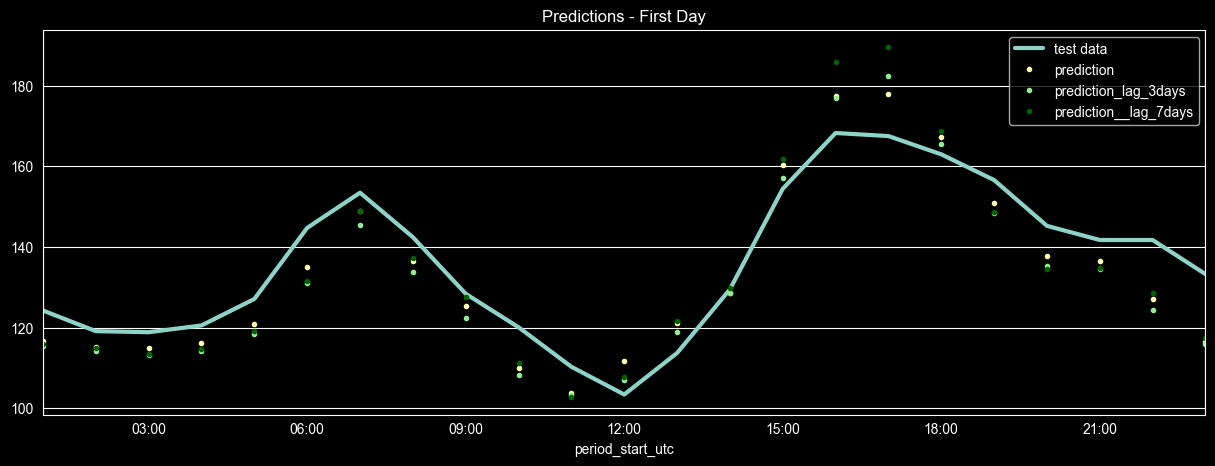

In [161]:
split_date_plus_one_day = split_date + relativedelta(days=1)

ax = df.loc[(split_date < df.index) & (df.index < split_date_plus_one_day)]['price'].plot(figsize=(15, 5), linewidth=3, title='Predictions - First Day')
df.loc[(split_date < df.index) & (df.index < split_date_plus_one_day)]['prediction'].plot(ax=ax, style='.')
df.loc[(split_date < df.index) & (df.index < split_date_plus_one_day)]['prediction_lag_3days'].plot(ax=ax, style='.', color='lightgreen')
df.loc[(split_date < df.index) & (df.index < split_date_plus_one_day)]['prediction_lag_7days'].plot(ax=ax, style='.', color='darkgreen')
plt.legend(['test data', 'prediction', 'prediction_lag_3days', 'prediction__lag_7days'])
plt.show()

# Summary and Model Comparison

In this notebook we have looked into different ways of feature engineering. Let us compare these different methods and their outcome. The most straightforward way of comparison is first looking at the root-mean-square error and the mean absolute error.

First we look at the errors for the first day after the training data.

Remark that the random search results change with every run of the notebook due to its random behavior. We have seen better RSME in the random search than in the original model. However, we have also seen instance where the RSME was worse for the random search than for the original model whereas in the same instance the MAE was way better for the random search than for the original model. So in this instance one model was better in RMSE while the other model was better in MAE.

You may rerun the whole notebook to compare different results for the random search.

In [159]:
# create the data for a pandas data frame
results_day = {
    'Algorithm': ['XGBoost', '... with GridSearch', '... with RandomSearch', '... with 3 days gas price lag', '... with 7 days gas price lag'],
    'RMSE in EUR/MWh': [round(rmse_day, 2), round(rmse_day_grid_search, 2), round(rmse_day_random_search, 2), round(rmse_day_lag_3days, 2), round(rmse_day_lag_7days, 2)],
    'MAE in EUR/MWh': [round(mae_day, 2), round(mae_day_grid_search, 2), round(mae_day_random_search, 2), round(mae_day_lag_3days, 2), round(mae_day_lag_7days, 2)]
}

# create the pandas data frame and print it
results_day_frame = pd.DataFrame(data=results_day)
results_day_frame

,Algorithm,RMSE in EUR/MWh,MAE in EUR/MWh
0,XGBoost,7.96,7.14
1,... with GridSearch,9.92,8.60
2,... with RandomSearch,8.57,5.77
3,... with 3 days gas price lag,9.35,8.31
4,... with 7 days gas price lag,9.81,8.45


Let's look at the visualization for the first day.

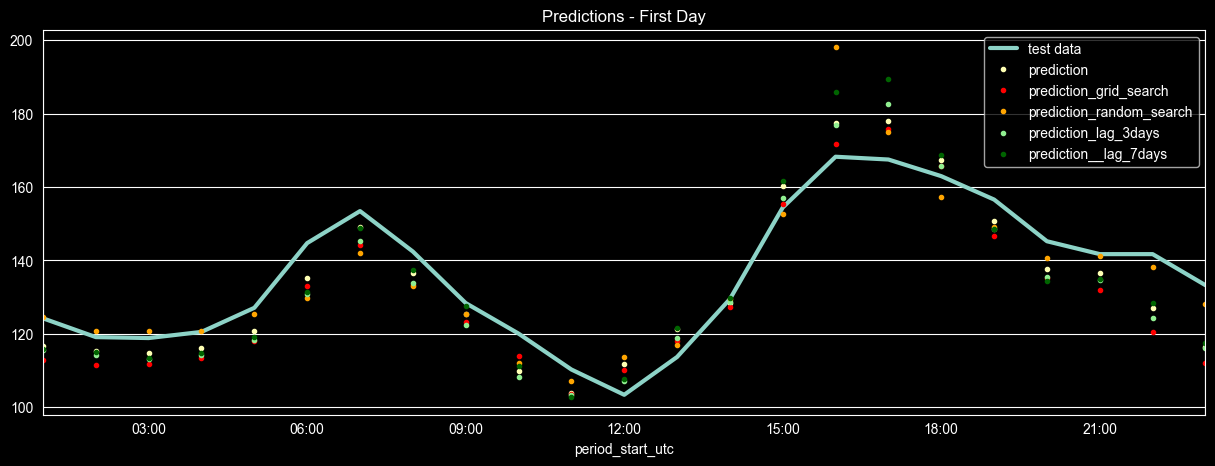

In [162]:
split_date_plus_one_day = split_date + relativedelta(days=1)

ax = df.loc[(split_date < df.index) & (df.index < split_date_plus_one_day)]['price'].plot(figsize=(15, 5), linewidth=3, title='Predictions - First Day')
df.loc[(split_date < df.index) & (df.index < split_date_plus_one_day)]['prediction'].plot(ax=ax, style='.')
df.loc[(split_date < df.index) & (df.index < split_date_plus_one_day)]['prediction_grid_search'].plot(ax=ax, style='.', color='red')
df.loc[(split_date < df.index) & (df.index < split_date_plus_one_day)]['prediction_random_search'].plot(ax=ax, style='.', color='orange')
df.loc[(split_date < df.index) & (df.index < split_date_plus_one_day)]['prediction_lag_3days'].plot(ax=ax, style='.', color='lightgreen')
df.loc[(split_date < df.index) & (df.index < split_date_plus_one_day)]['prediction_lag_7days'].plot(ax=ax, style='.', color='darkgreen')
plt.legend(['test data', 'prediction', 'prediction_grid_search', 'prediction_random_search', 'prediction_lag_3days', 'prediction__lag_7days'])
plt.show()

Now we look at the whole testing period.

Remark again that the random search results change with every run of the notebook due to its random behavior. During our testing we have seen an RMSE of 22.89 EUR/MWh which places it as the very best model, but also values that have been quite worse compared to the original XGBoost model.

In [158]:
# create the data for a pandas data frame
results_period = {
    'Algorithm': ['XGBoost', '... with GridSearch', '... with RandomSearch', '... with 3 days gas price lag', '... with 7 days gas price lag'],
    'RMSE in EUR/MWh': [round(rmse_period, 2), round(rmse_period_grid_search, 2), round(rmse_period_random_search, 2), round(rmse_period_lag_3days, 2), round(rmse_period_lag_7days, 2)],
    'MAE in EUR/MWh': [round(mae_period, 2), round(mae_period_grid_search, 2), round(mae_period_random_search, 2), round(mae_period_lag_3days, 2), round(mae_period_lag_7days, 2)]
}

# create the pandas data frame and print it
results_period_frame = pd.DataFrame(data=results_period)
results_period_frame

,Algorithm,RMSE in EUR/MWh,MAE in EUR/MWh
0,XGBoost,25.84,17.46
1,... with GridSearch,27.10,18.41
2,... with RandomSearch,22.89,14.39
3,... with 3 days gas price lag,26.85,18.55
4,... with 7 days gas price lag,26.94,18.71


Another interesting insight is looking at the feature importance across the different models. Let's look at the models without lag. Even though we use the exact same data, depending on the hyperparameters of the models we get very different results.

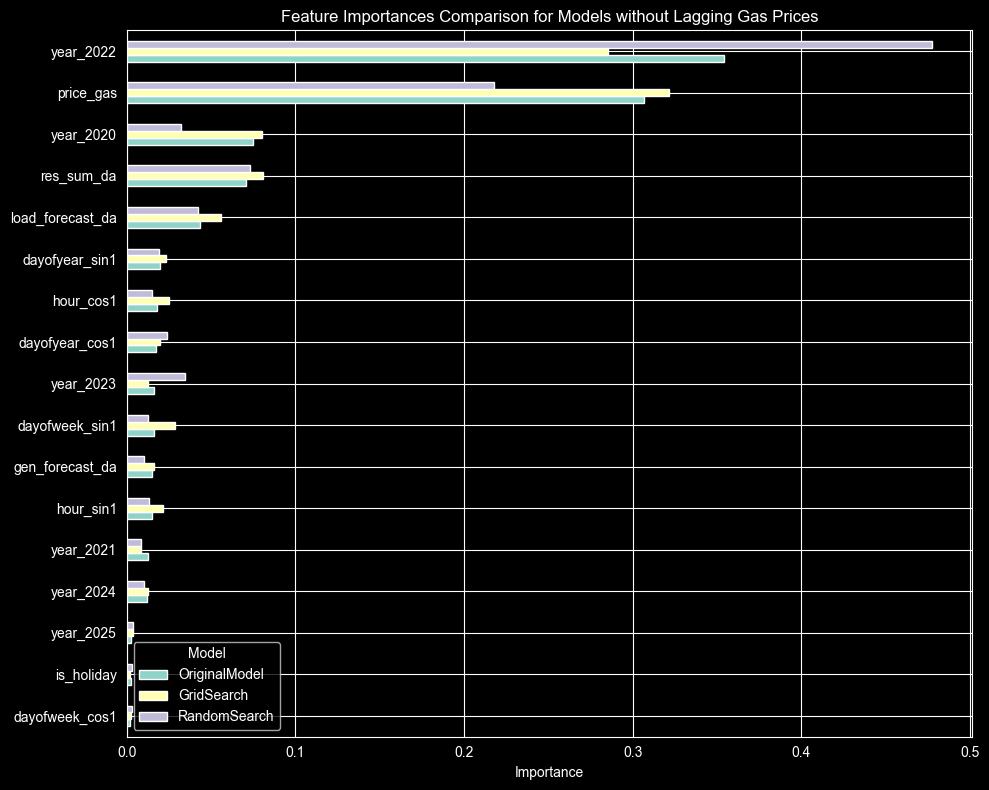

In [173]:
# Put your models in a dictionary
models = {
    "OriginalModel": reg,
    "GridSearch": grid_search_best_model,
    "RandomSearch": random_search_best_model,
}

# Create a dataframe with feature importances from all models
fi = pd.DataFrame({
    name: model.feature_importances_
    for name, model in models.items()
}, index=reg.feature_names_in_)  # assumes all models use same features

# Sort by one model (optional)
fi = fi.sort_values(by="OriginalModel")

# Plot
fi.plot(kind='barh', figsize=(10, 8))
plt.title("Feature Importances Comparison for Models without Lagging Gas Prices")
plt.xlabel("Importance")
plt.legend(title="Model")
plt.tight_layout()
plt.show()